<a href="https://colab.research.google.com/github/hey870922/RFM-Analysis/blob/main/RFM_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("RFM_Raw.csv", encoding = "big5")
df.head()

,Date,InvoNo,CustomerKey,交易金額
0,2018/1/1,JA1803995,A0620,411.400
1,2018/1/1,JA1805774,A1336,658.240
2,2018/1/1,JA1801197,A0786,1892.352
3,2018/1/2,JA1805224,A0937,411.400
4,2018/1/2,JA1802973,A1371,411.400


In [4]:
import pandas as pd

df['Date'] = pd.to_datetime(df['Date'])
global_max_date = df['Date'].max()

result_df = df.groupby('CustomerKey').agg(
    F=('InvoNo', 'count'),
    M=('交易金額', 'sum'),
    max_date=('Date', 'max')
).reset_index()

result_df['R'] = (global_max_date - result_df['max_date']).dt.days
result_df = result_df.rename(columns={'CustomerKey': 'customer'})
result_df = result_df[['customer', 'F', 'M', 'R']]

print(result_df)

    customer   F            M   R
0      A0350  25  51238.11440   9
1      A0351   6  17890.31200  16
2      A0352  14  46424.03852  14
3      A0353  14  27607.68636  24
4      A0354   6   9973.92064  31
..       ...  ..          ...  ..
727    A1413  23  52738.79456  10
728    A1415  20  53019.49664  17
729    A1416  24  49938.38378   4
730    A1419  22  64257.84520  50
731    A1420  14  25054.18342  85

[732 rows x 4 columns]


In [8]:
result_df.to_csv("RFM_Data.csv", index = False)

In [10]:
from sklearn.preprocessing import MinMaxScaler

# 複製一份資料進行正規化
nrfm = result_df.copy()

# 建立 MinMaxScaler 實例
scaler = MinMaxScaler()

# 對 R, F, M 進行正規化
nrfm[['R', 'F', 'M']] = scaler.fit_transform(nrfm[['R', 'F', 'M']])

# 顯示處理後的結果
display(nrfm.head())

,customer,F,M,R
0,A0350,0.631579,0.376563,0.024523
1,A0351,0.131579,0.127866,0.043597
2,A0352,0.342105,0.340662,0.038147
3,A0353,0.342105,0.200335,0.065395
4,A0354,0.131579,0.068827,0.084469


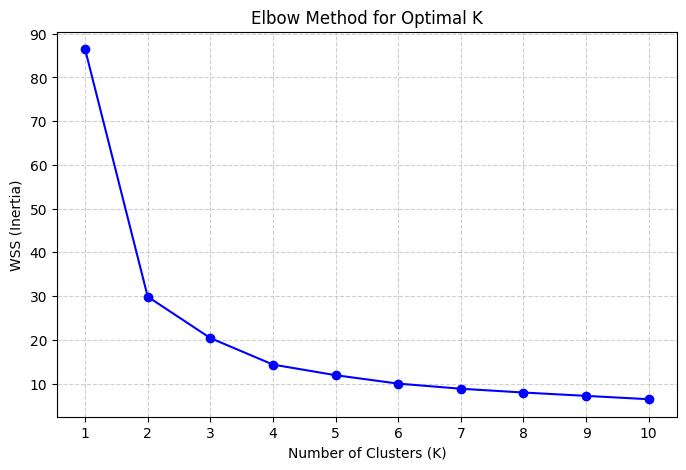

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 提取用於聚類的特徵：R, F, M
X = nrfm[['R', 'F', 'M']]

# 計算不同群數下的 WSS (Inertia)
wss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wss.append(kmeans.inertia_)

# 繪製手肘法圖表
plt.figure(figsize=(8, 5))
plt.plot(k_range, wss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WSS (Inertia)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [12]:
from sklearn.cluster import KMeans

# 設定 K-means 分群數為 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# 進行分群預測
nrfm['Cluster'] = kmeans.fit_predict(nrfm[['R', 'F', 'M']])

# 同時將群組標籤加回未經正規化的原始資料 result_df，便於後續進行特徵解讀
result_df['Cluster'] = nrfm['Cluster']

# 顯示分群後的樣本分佈與前幾筆資料
print(result_df['Cluster'].value_counts())
display(result_df.head())

Cluster
2    321
1    221
3    114
0     76
Name: count, dtype: int64


,customer,F,M,R,Cluster
0,A0350,25,51238.11440,9,1
1,A0351,6,17890.31200,16,2
2,A0352,14,46424.03852,14,1
3,A0353,14,27607.68636,24,1
4,A0354,6,9973.92064,31,2


In [13]:
# 建立客人群組對照表 (customer -> Cluster)
cluster_map = result_df.set_index('customer')['Cluster']

# 將對照後的群組貼回原始交易資料 df
df['Cluster'] = df['CustomerKey'].map(cluster_map)

# 顯示合併後的原始交易資料前幾筆
display(df.head())

,Date,InvoNo,CustomerKey,交易金額,Cluster
0,2018-01-01,JA1803995,A0620,411.400,0
1,2018-01-01,JA1805774,A1336,658.240,2
2,2018-01-01,JA1801197,A0786,1892.352,2
3,2018-01-02,JA1805224,A0937,411.400,1
4,2018-01-02,JA1802973,A1371,411.400,2


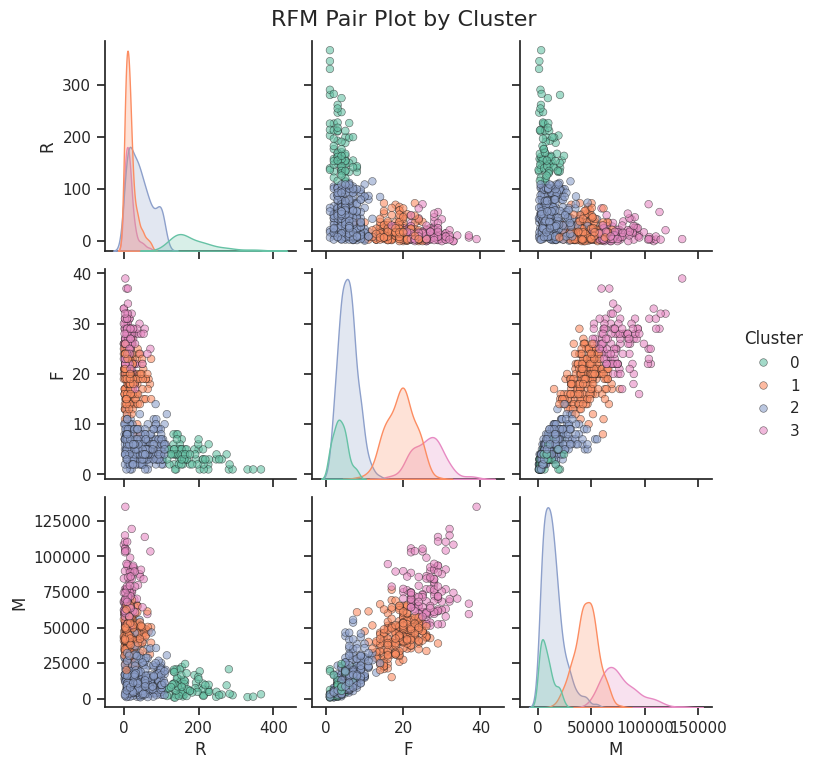

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設定繪圖風格與字型
sns.set_theme(style="ticks")

# 繪製 Pair Plot，使用 Cluster 欄位進行著色分組
# 這裡使用每個客戶一筆資料的 result_df，最能看清 R、F、M 與群組的關係
g = sns.pairplot(
    result_df,
    vars=['R', 'F', 'M'],
    hue='Cluster',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'}
)

g.fig.suptitle('RFM Pair Plot by Cluster', y=1.02, fontsize=16)
plt.show()

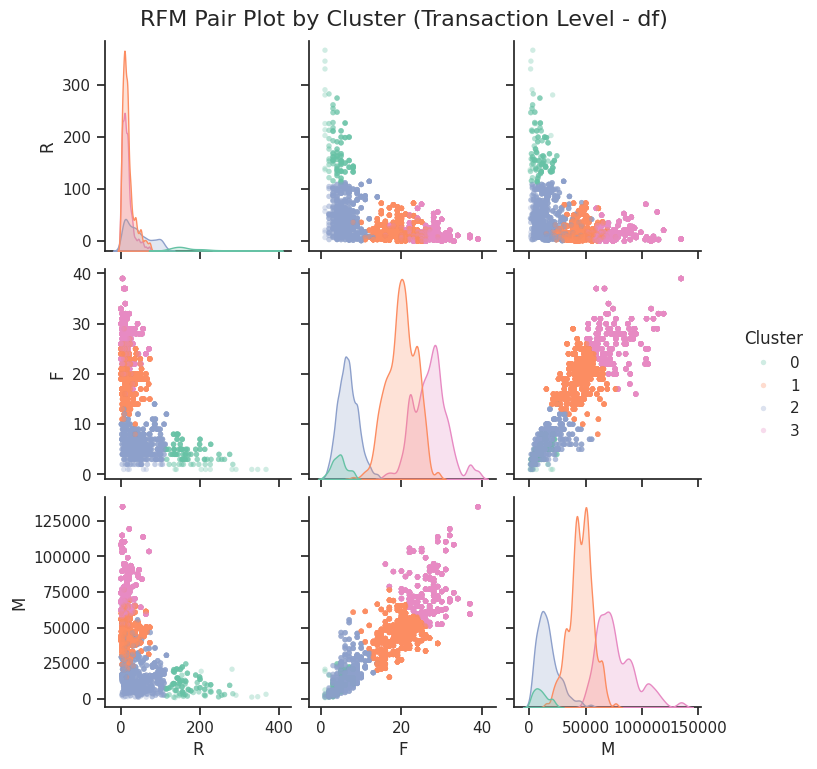

In [16]:
# 將 result_df 的 R, F, M 欄位合併回原始交易資料 df
if 'R' not in df.columns or 'F' not in df.columns or 'M' not in df.columns:
    df = df.merge(result_df[['customer', 'R', 'F', 'M']], left_on='CustomerKey', right_on='customer', how='left')

# 繪製 Pair Plot，使用 df 的 R、F、M 欄位並以 Cluster 分組
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")
g = sns.pairplot(
    df,
    vars=['R', 'F', 'M'],
    hue='Cluster',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15, 'edgecolor': 'none'}
)

g.fig.suptitle('RFM Pair Plot by Cluster (Transaction Level - df)', y=1.02, fontsize=16)
plt.show()

In [17]:
# 定定義群組名稱的對照字典
group_mapping = {
    0: 'Missing',
    1: 'High',
    2: 'Low',
    3: 'Medium'
}

# 新增 Group 欄位並進行對照轉換
df['Group'] = df['Cluster'].map(group_mapping)

# 顯示新增欄位後的原始資料前幾筆與分組統計
print(df['Group'].value_counts())
display(df.head())

Group
High       4269
Medium     3006
Low        1828
Missing     278
Name: count, dtype: int64


,Date,InvoNo,CustomerKey,交易金額,Cluster,customer,R,F,M,Group
0,2018-01-01,JA1803995,A0620,411.400,0,A0620,262,3,2950.33200,Missing
1,2018-01-01,JA1805774,A1336,658.240,2,A1336,28,6,15468.37280,Low
2,2018-01-01,JA1801197,A0786,1892.352,2,A0786,16,9,15628.44360,Low
3,2018-01-02,JA1805224,A0937,411.400,1,A0937,11,18,42053.32092,High
4,2018-01-02,JA1802973,A1371,411.400,2,A1371,8,8,9370.46120,Low


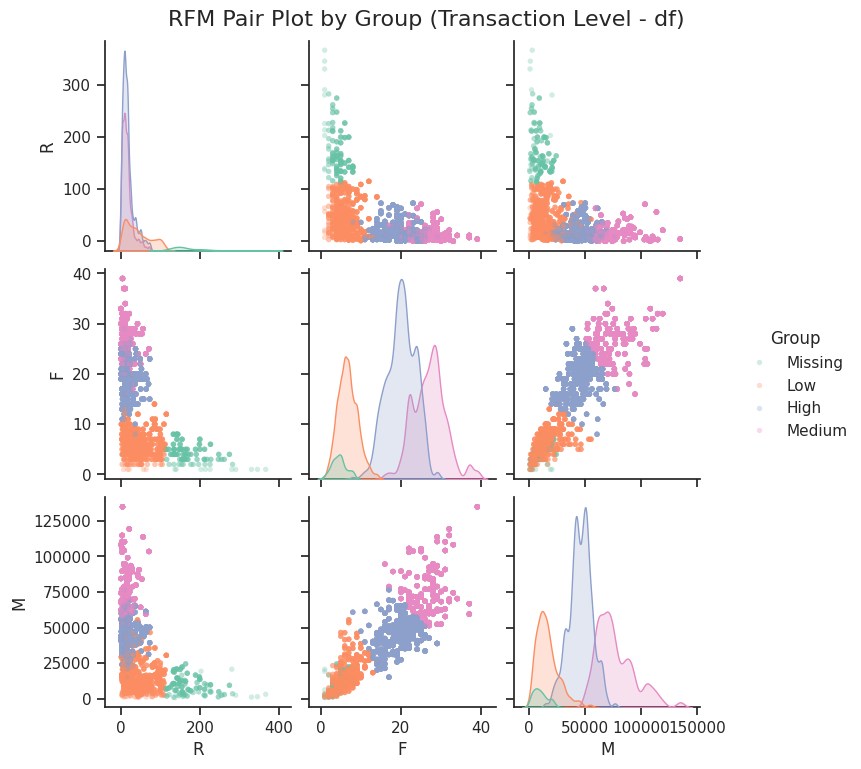

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設定繪圖風格
sns.set_theme(style="ticks")

# 繪製 Pair Plot，使用 df 的 R、F、M 欄位，並以 Group 進行著色分組
g = sns.pairplot(
    df,
    vars=['R', 'F', 'M'],
    hue='Group',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15, 'edgecolor': 'none'}
)

g.fig.suptitle('RFM Pair Plot by Group (Transaction Level - df)', y=1.02, fontsize=16)
plt.show()

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# 設定繪圖風格
sns.set_theme(style="ticks")

# 繪製 Pair Plot，使用 df 的 R、F、M 欄位，並以 Group 進行著色分組
g = sns.pairplot(
    df,
    vars=['R', 'F', 'M'],
    hue='Group',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15, 'edgecolor': 'none'}
)

g.fig.suptitle('RFM Pair Plot by Group (Transaction Level - df)', y=1.02, fontsize=16)

# 儲存為透明背景的 PNG 格式
plt.savefig('RFM_Pairplot.png', dpi=300, bbox_inches='tight', transparent=True)
plt.close()

# 執行下載檔案
files.download('RFM_Pairplot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
from google.colab import files

# 將 df 匯出為 CSV 檔，使用 UTF-8 附帶 BOM 編碼以確保 Excel 開啟時中文不會亂碼
df.to_csv('RFM_result.csv', index=False, encoding='utf-8-sig')

# 下載產生的 CSV 檔案
files.download('RFM_result.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>